## Recitation 7: Monte Carlo Simulation

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa

%matplotlib inline

### Problem 1

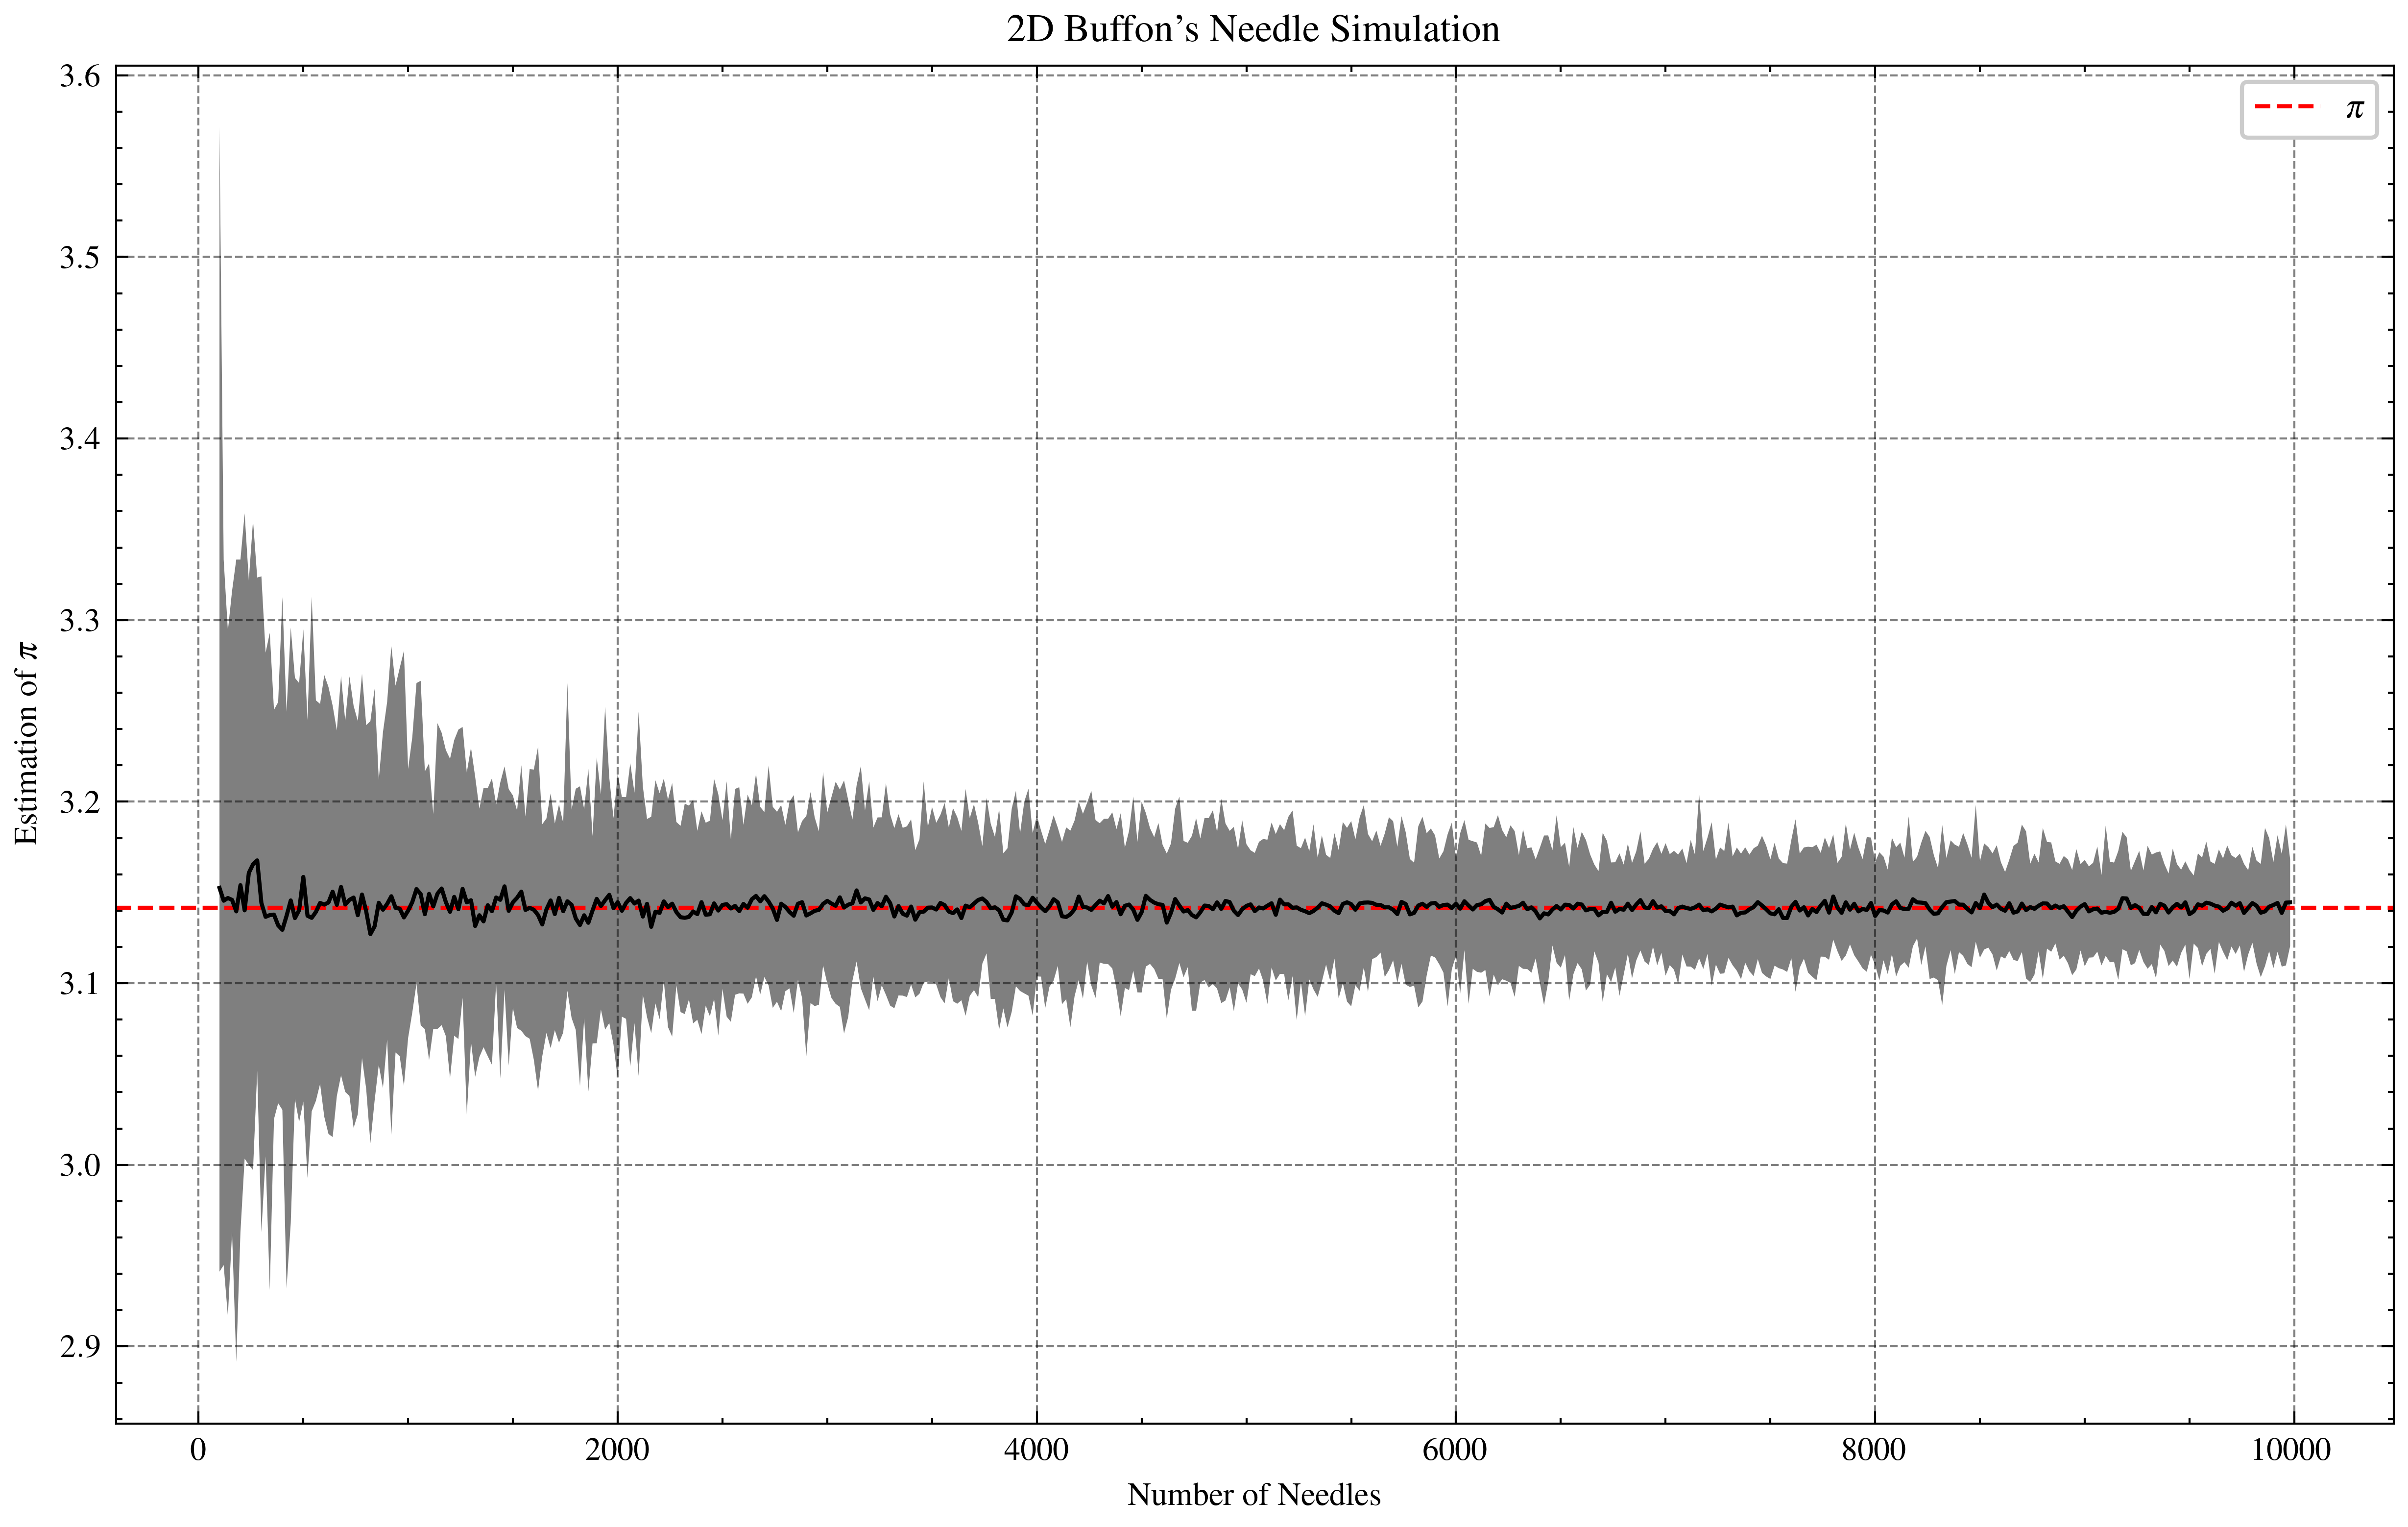

In [2]:
START = 100
END = 10000
STEP = 20
NUM = 40


def throw_needle(num):
    """simulate needle throwing for a given number"""
    rng = np.random.default_rng(int(time.time() * 100000))
    x = rng.uniform(0, 1 / 2, num)
    y = rng.uniform(0, 1 / 2, num)
    theta = rng.uniform(0, np.pi / 2, num)

    hits = np.sum(x <= 0.5 * np.sin(theta)) + np.sum(y <= 0.5 * np.cos(theta))
    return 4 / (hits / num)


needle_nums = np.arange(START, END, step=STEP, dtype=int)

all_estimates = []
for i in range(NUM):
    estimates = [throw_needle(num) for num in needle_nums]
    all_estimates.append(estimates)

all_estimates = np.array(all_estimates)
up = np.max(all_estimates, axis=0)
down = np.min(all_estimates, axis=0)
mean = np.mean(all_estimates, axis=0)

plt.style.use(["science", "ieee", "grid"])

fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(needle_nums, up, down, alpha=0.5, linewidth=0)
ax.axhline(y=np.pi, color="r", linestyle="--", label="$\\pi$")
ax.plot(needle_nums, mean)
ax.set_xlabel("Number of Needles")
ax.set_ylabel("Estimation of $\\pi$")
ax.set_title("2D Buffon's Needle Simulation")
ax.legend()

plt.show()

### Problem 2

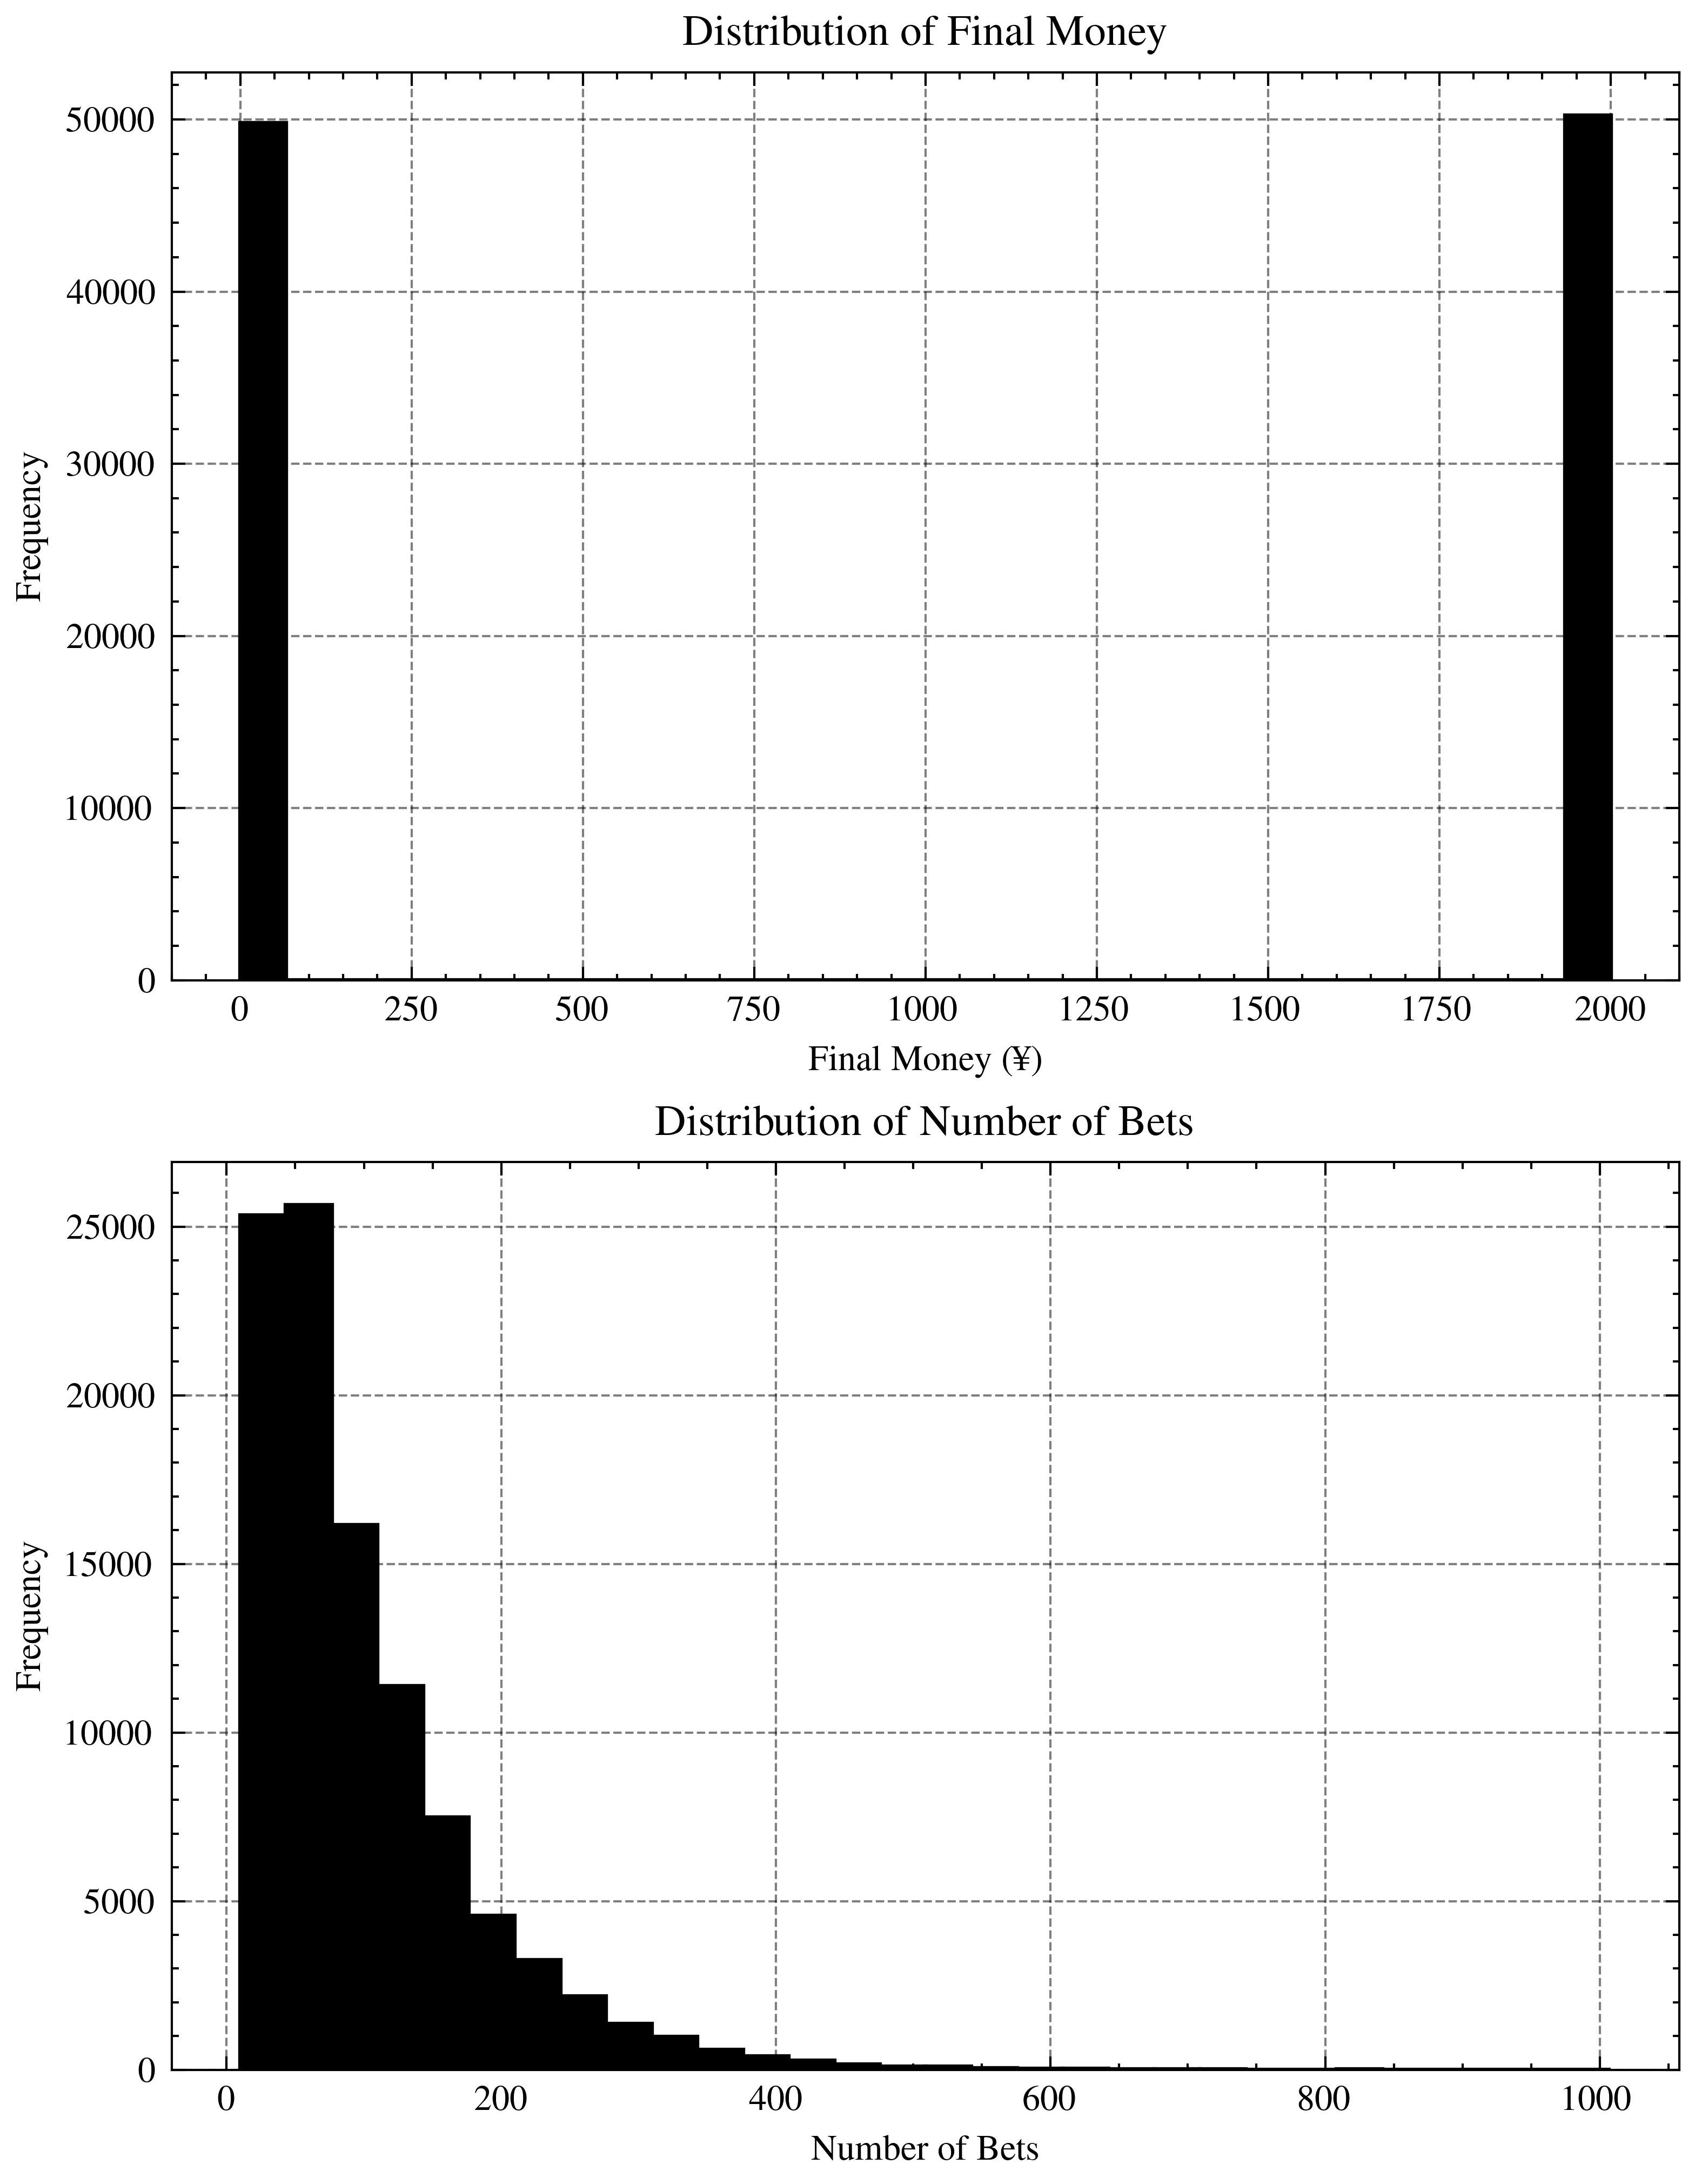

(a) The probability that the player leaves the casino with ¥2000 is 0.5023
(b) The average amount of money the player leaves the casino with is ¥1004.6000
(c) The average number of bets the player makes before stopping is 99.4794


In [3]:
STARTING_MONEY = 1000
BET_AMOUNT = 100
WIN_MONEY = 2000
LOSE_MONEY = 0
NUM_SIMULATIONS = 100000


def roulette_simulation():
    """
    returns the amount of money left after the player stops playing and the number of bets made
    """
    current_money = np.full(NUM_SIMULATIONS, STARTING_MONEY)
    num_bets = np.zeros(NUM_SIMULATIONS, dtype=int)
    active = np.ones(NUM_SIMULATIONS, dtype=bool)

    rng = np.random.default_rng(int(time.time()))

    while np.any(active):
        bets = rng.random(size=NUM_SIMULATIONS) < 0.5
        current_money[active] += np.where(bets[active], BET_AMOUNT, -BET_AMOUNT)
        num_bets[active] += 1
        active = (current_money > LOSE_MONEY) & (current_money < WIN_MONEY)

    return current_money, num_bets


def monte_carlo_simulation():
    final_money, num_bets = roulette_simulation()
    wins = np.sum(final_money >= WIN_MONEY)
    avg_money_left = np.mean(final_money)
    avg_num_bets = np.mean(num_bets)

    plt.style.use(["science", "ieee", "grid"])
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(6, 8))

    # Histogram for final_money
    ax0.hist(final_money, bins=30, edgecolor="black")
    ax0.set_title("Distribution of Final Money")
    ax0.set_xlabel("Final Money (¥)")
    ax0.set_ylabel("Frequency")

    # Histogram for num_bets
    ax1.hist(num_bets, bins=30, edgecolor="black")
    ax1.set_title("Distribution of Number of Bets")
    ax1.set_xlabel("Number of Bets")
    ax1.set_ylabel("Frequency")

    plt.show()

    return wins / NUM_SIMULATIONS, avg_money_left, avg_num_bets


win_probability, avg_money_left, avg_num_bets = monte_carlo_simulation()

print(
    f"(a) The probability that the player leaves the casino with ¥2000 is {win_probability:.4f}"
)
print(
    f"(b) The average amount of money the player leaves the casino with is ¥{avg_money_left:.4f}"
)
print(
    f"(c) The average number of bets the player makes before stopping is {avg_num_bets:.4f}"
)

### Problem 3

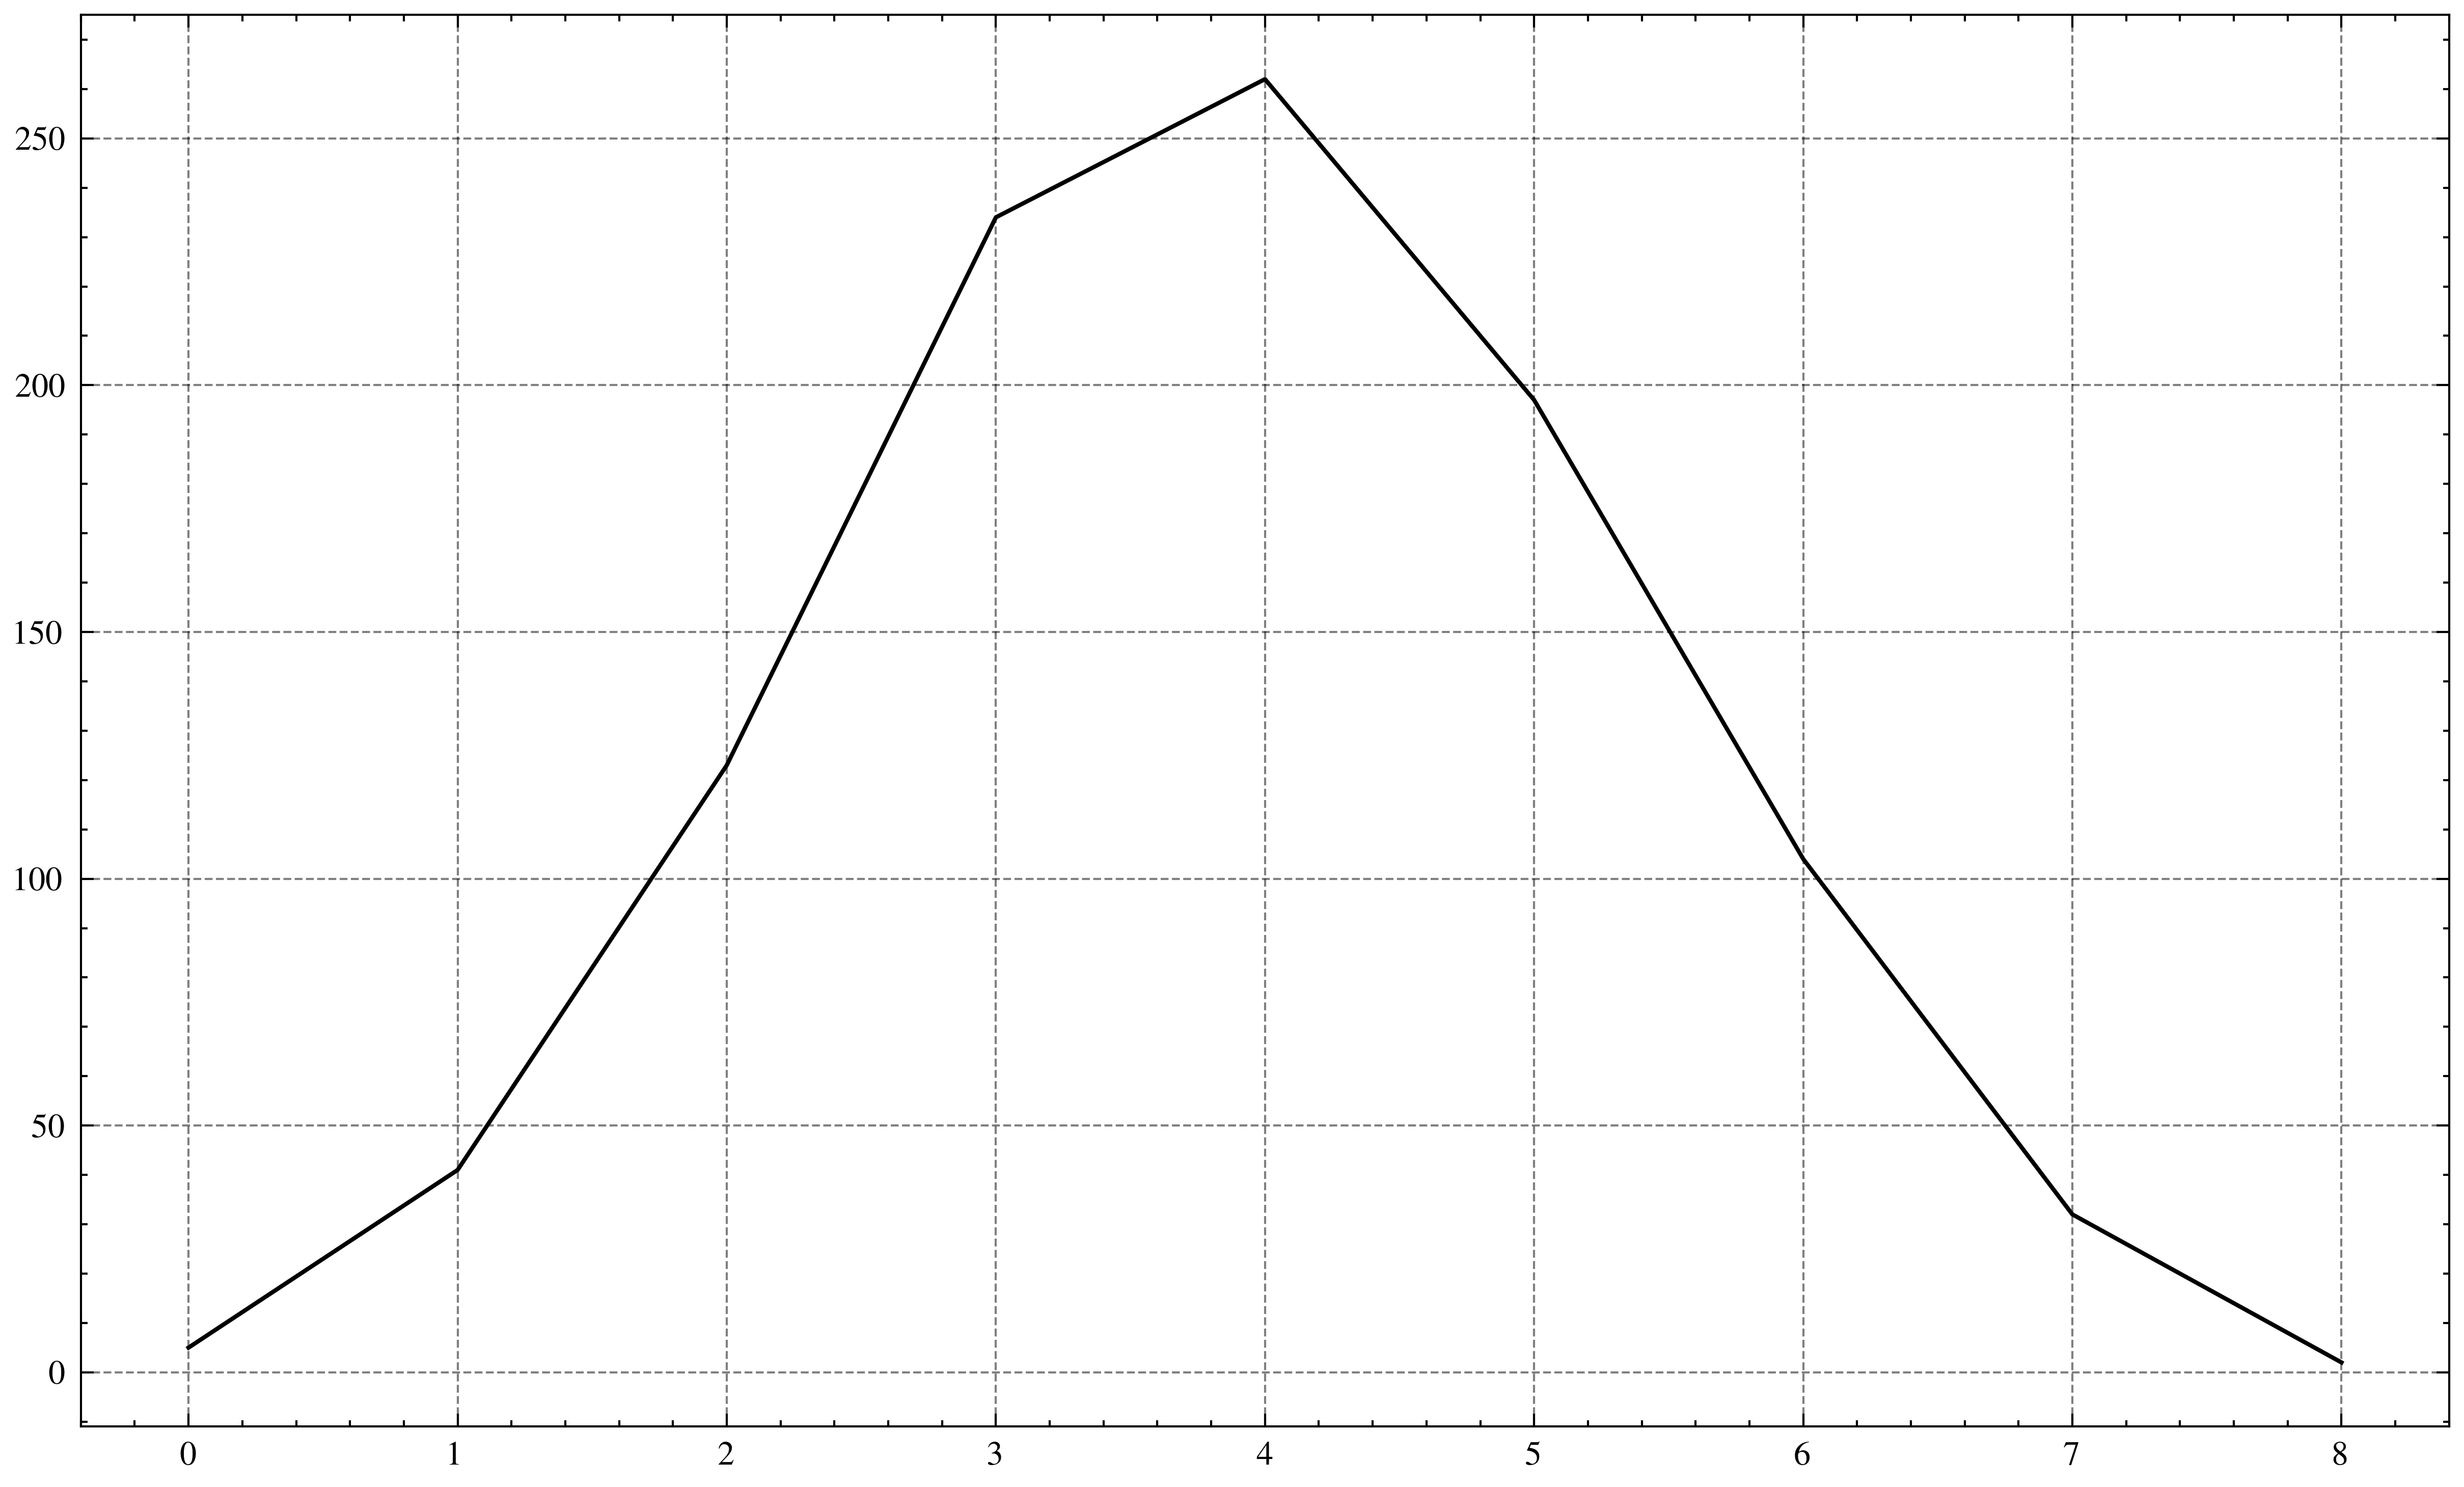

array([0.005, 0.041, 0.123, 0.234, 0.262, 0.197, 0.104, 0.032, 0.002])

In [4]:
n = 1000
N = 8
result = np.zeros(N + 1)
for i in range(n):
    x = np.random.randint(0, 2, N)
    s = np.sum(x)
    result[s] += 1

plt.style.use(["science", "ieee", "grid"])
plt.subplots(figsize=(10, 6))
plt.plot(range(N + 1), result)
plt.show()
result / n